In [30]:
import ast
import re
from utils.analyse_results import GraphsTraining, Results, load_all_pickles, plot_time_bands, plot_time_bands_median, Graphs
import pandas as pd
import numpy as np
import pickle
from pathlib import Path
train_info = GraphsTraining()

## Load JAX results in

In [31]:
results_jax_seeds = load_all_pickles("results/jax_rl_runs/jax_rl_2026-02-07_05-44-40", recursive=False)
r_seeds_jax = results_jax_seeds[0]
r_seeds_jax_no_logs = results_jax_seeds[1]

Loaded results/jax_rl_runs/jax_rl_2026-02-07_05-44-40/results_NO_logging.pkl
Loaded results/jax_rl_runs/jax_rl_2026-02-07_05-44-40/results_WITH_logging.pkl

Loaded 2 files from results/jax_rl_runs/jax_rl_2026-02-07_05-44-40


In [32]:
r_seeds_jax[list(r_seeds_jax.keys())[2]]

{'times_elapsed_split': [23.56004309654236],
 'times_elapsed': 23.56004309654236,
 'mse_diffrax': 0.08339903407869485,
 'mse_diffrax_test': 0.8297910480008852}

In [33]:
def format_jax(path):
    r_no_logs, r_w_logs = load_all_pickles(path, recursive=False)

    df_no_logs = (
        pd.DataFrame(r_no_logs).T
        .reset_index()
        .rename(columns={"level_0": "params", "level_1": "date", "level_2": "seed"})
    )
    del r_w_logs["training_losses"]
    df_w_logs = (
        pd.DataFrame(r_w_logs).T
        .reset_index()
    )
    
    if len(df_w_logs[0].iloc[0][0]) == 0:
        df_w_logs = df_w_logs.rename(
                columns={
                    "level_0": "params",
                    "level_1": "date",
                    "level_2": "seed",
                    0: "times_elapsed",
                    1: "training_losses",
                }
            )
    else:
        df_w_logs = df_w_logs.rename(
                columns={
                    "level_0": "params",
                    "level_1": "date",
                    "level_2": "seed",
                    0: "training_losses",
                }
            )        

    # Overwrite times with the no-log timings
    df_w_logs["times_elapsed"] = df_no_logs["times_elapsed"].values

    df_w_logs["layer_width"] = df_w_logs["params"].apply(lambda x: x[0])
    df_w_logs["n_epochs"] = df_w_logs["params"].apply(lambda x: x[2])
    df_w_logs["mse_train_log"] = df_w_logs["training_losses"].apply(lambda x: x[0])
    df_w_logs["mse_test_log"]  = df_w_logs["training_losses"].apply(lambda x: x[1])
    df_w_logs["n_records"] = df_w_logs["mse_train_log"].apply(len)
    df_w_logs["t_per_segment"] = df_w_logs["times_elapsed"] / df_w_logs["n_records"]

    df_tmp = df_w_logs.assign(
        epoch_logs=lambda d: d.apply(
            lambda r: [((i + 1) * r["t_per_segment"], vt, vs, i * r["n_records"])
                       for i, (vt, vs) in enumerate(zip(r["mse_train_log"], r["mse_test_log"]))],
            axis=1,
        )
    )

    long = (
        df_tmp
        .explode("epoch_logs")
        .assign(
            time=lambda d: d["epoch_logs"].str[0],
            mse_train_log=lambda d: d["epoch_logs"].str[1],
            mse_test_log=lambda d: d["epoch_logs"].str[2],
            n_epochs_ =lambda d: d["epoch_logs"].str[2],
        )
        .drop(columns=["epoch_logs", "training_losses", "params", "times_elapsed", "n_epochs", "n_records"])
        .reset_index(drop=True)
    )

    return long

# different seeds
df_results_seeds = format_jax("results/jax_rl_runs/jax_rl_2026-02-01_01-20-21")

# different dates
df_results_dates = format_jax("results/jax_rl_runs/jax_rl_2026-02-06_17-15-15")

Loaded results/jax_rl_runs/jax_rl_2026-02-01_01-20-21/results_NO_logging.pkl
Loaded results/jax_rl_runs/jax_rl_2026-02-01_01-20-21/results_WITH_logging.pkl

Loaded 2 files from results/jax_rl_runs/jax_rl_2026-02-01_01-20-21
Loaded results/jax_rl_runs/jax_rl_2026-02-06_17-15-15/results_NO_logging.pkl
Loaded results/jax_rl_runs/jax_rl_2026-02-06_17-15-15/results_WITH_logging.pkl

Loaded 2 files from results/jax_rl_runs/jax_rl_2026-02-06_17-15-15


In [34]:
df_results_seeds.groupby("layer_width").agg({"time": "max", "mse_train_log": "last", "mse_test_log": "last"})

,time,mse_train_log,mse_test_log
layer_width,,,
"[7, 128, 1]",173.319992,0.009909,0.139474
"[7, 16, 1]",59.364315,0.012581,0.167833
"[7, 32, 1]",75.689897,0.012273,0.180639
"[7, 4, 1]",49.255685,0.115394,1.531563
"[7, 64, 1]",104.432974,0.009936,0.135205
"[7, 8, 1]",50.425620,0.065704,0.574735


In [35]:
df_results_dates.groupby("layer_width").agg({"time": "max", "mse_train_log": "last", "mse_test_log": "last"})

,time,mse_train_log,mse_test_log
layer_width,,,
"[7, 128, 1]",137.291570,0.008519,0.495205
"[7, 16, 1]",39.280203,0.019070,0.394501
"[7, 32, 1]",49.843528,0.011823,0.683451
"[7, 4, 1]",26.966372,0.037460,0.270849
"[7, 64, 1]",78.640901,0.011986,0.412504
"[7, 8, 1]",31.481091,0.049060,0.903138


## Load Pyomo results in
* the first script is iterating over 15 different seeds with the same set of data

In [36]:
def results_to_df(results: dict) -> pd.DataFrame:
    rows = []
    for (cfg, date, seed), vals in results.items():
        layer_sizes, penalty, tol = cfg  # cfg is the first tuple element
        r = vals.get("result", {})
        rows.append(
            {
                "layer_sizes": layer_sizes,
                "penalty": penalty,
                "tol": tol,
                "date": date,
                "seed": seed,
                "solver_time": r.get("solver_time"),
                "termination": getattr(r.get("termination_condition"), "value", r.get("termination_condition")),
                "message": r.get("message"),
                "times_elapsed": vals.get("times_elapsed"),
                "mse_odeint": vals.get("mse_odeint"),
                "mse_coll_ode": vals.get("mse_coll_ode"),
                "mse_odeint_test": vals.get("mse_odeint_test"),
                "mse_coll_ode_test": vals.get("mse_coll_ode_test"),
            }
        )
    return pd.DataFrame(rows)

In [37]:
results_pyomo = load_all_pickles("results/pyomo_network_size/pyomo_rl_2026-01-26_22-38-00", recursive=False)[0]
pyomo_df_seeds = results_to_df(results_pyomo)

results_pyomo = load_all_pickles("results/pyomo_network_size/pyomo_rl_2026-01-26_23-10-42", recursive=False)[0]
pyomo_df_dates = results_to_df(results_pyomo)

Loaded results/pyomo_network_size/pyomo_rl_2026-01-26_22-38-00/results_full.pkl

Loaded 1 files from results/pyomo_network_size/pyomo_rl_2026-01-26_22-38-00
Loaded results/pyomo_network_size/pyomo_rl_2026-01-26_23-10-42/results_full.pkl

Loaded 1 files from results/pyomo_network_size/pyomo_rl_2026-01-26_23-10-42


In [38]:
pyomo_df_seeds

,layer_sizes,penalty,tol,date,seed,solver_time,termination,message,times_elapsed,mse_odeint,mse_coll_ode,mse_odeint_test,mse_coll_ode_test
0,"[7, 4, 1]",0.00001,0.000001,2015-01-15,2203719317,5.673489,optimal,Ipopt 3.14.19\x3a Optimal Solution Found,5.673489,0.014837,0.015588,0.177485,0.178288
1,"[7, 4, 1]",0.00001,0.000001,2015-01-15,2478910640,2.835778,optimal,Ipopt 3.14.19\x3a Optimal Solution Found,2.835778,404.831988,0.167306,174.721276,0.281408
2,"[7, 4, 1]",0.00001,0.000001,2015-01-15,1200230824,3.127980,optimal,Ipopt 3.14.19\x3a Optimal Solution Found,3.127980,625.296349,0.142486,130.377190,0.278824
3,"[7, 4, 1]",0.00001,0.000001,2015-01-15,4160408464,2.456779,optimal,Ipopt 3.14.19\x3a Optimal Solution Found,2.456779,52.048997,0.145179,34.695952,0.386349
4,"[7, 4, 1]",0.00001,0.000001,2015-01-15,5418038,3.204795,optimal,Ipopt 3.14.19\x3a Optimal Solution Found,3.204795,0.025085,0.022450,0.365002,0.379181
...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,"[7, 128, 1]",0.00001,0.000001,2015-01-15,2226831218,62.419063,optimal,Ipopt 3.14.19\x3a Optimal Solution Found,62.419063,0.008301,0.008416,0.130492,0.131439
86,"[7, 128, 1]",0.00001,0.000001,2015-01-15,2324457501,28.075830,optimal,Ipopt 3.14.19\x3a Optimal Solution Found,28.075830,4898.806340,0.046627,1054.563376,0.169852
87,"[7, 128, 1]",0.00001,0.000001,2015-01-15,1504166862,54.164645,optimal,Ipopt 3.14.19\x3a Optimal Solution Found,54.164645,0.008277,0.008457,0.135610,0.135484
88,"[7, 128, 1]",0.00001,0.000001,2015-01-15,823387748,33.429252,optimal,Ipopt 3.14.19\x3a Optimal Solution Found,33.429252,5277.282657,0.061055,1273.841387,0.164114


In [39]:
pyomo_df_seeds.head(1)

,layer_sizes,penalty,tol,date,seed,solver_time,termination,message,times_elapsed,mse_odeint,mse_coll_ode,mse_odeint_test,mse_coll_ode_test
0,"[7, 4, 1]",0.00001,0.000001,2015-01-15,2203719317,5.673489,optimal,Ipopt 3.14.19\x3a Optimal Solution Found,5.673489,0.014837,0.015588,0.177485,0.178288


In [40]:
pyomo_df_seeds.groupby("layer_sizes")[["times_elapsed","mse_coll_ode","mse_coll_ode_test"]].mean()

,times_elapsed,mse_coll_ode,mse_coll_ode_test
layer_sizes,,,
"[7, 128, 1]",48.628421,0.019632,0.151088
"[7, 16, 1]",6.882207,0.026704,0.176181
"[7, 32, 1]",11.930853,0.016799,0.166746
"[7, 4, 1]",3.160783,0.074757,0.911308
"[7, 64, 1]",26.076865,0.013454,0.142562
"[7, 8, 1]",3.960035,0.071949,0.694285


In [41]:
pyomo_df_seeds.head(1)

,layer_sizes,penalty,tol,date,seed,solver_time,termination,message,times_elapsed,mse_odeint,mse_coll_ode,mse_odeint_test,mse_coll_ode_test
0,"[7, 4, 1]",0.00001,0.000001,2015-01-15,2203719317,5.673489,optimal,Ipopt 3.14.19\x3a Optimal Solution Found,5.673489,0.014837,0.015588,0.177485,0.178288


In [42]:
df_results_seeds.groupby("layer_width").agg({"time": "max", "mse_train_log": "last", "mse_test_log": "last"})

,time,mse_train_log,mse_test_log
layer_width,,,
"[7, 128, 1]",173.319992,0.009909,0.139474
"[7, 16, 1]",59.364315,0.012581,0.167833
"[7, 32, 1]",75.689897,0.012273,0.180639
"[7, 4, 1]",49.255685,0.115394,1.531563
"[7, 64, 1]",104.432974,0.009936,0.135205
"[7, 8, 1]",50.425620,0.065704,0.574735


In [43]:
df_results_seeds.head(1)

,date,seed,layer_width,mse_train_log,mse_test_log,t_per_segment,time,n_epochs_
0,2015-01-15,2806773369,"[7, 4, 1]",1.126541,9.110467,0.21355,0.21355,9.110467


In [44]:
pyomo_df_dates.groupby("layer_sizes")[["times_elapsed","mse_coll_ode","mse_coll_ode_test"]].mean()

,times_elapsed,mse_coll_ode,mse_coll_ode_test
layer_sizes,,,
"[7, 128, 1]",39.523298,0.230798,2.569817
"[7, 16, 1]",6.120826,0.082831,0.690114
"[7, 32, 1]",9.938667,0.052270,1.825717
"[7, 4, 1]",3.432491,0.305992,0.628372
"[7, 64, 1]",19.620832,0.135422,1.098205
"[7, 8, 1]",3.855283,0.168406,1.406523


## Comparison

* boxplot - would need to make sure the timings are comparable (get the timings most similar to the Pyomo from JAX)
* pareto plot (but currently there is too much data for JAX, so again - picking the most similar timings perhaps?)

In [45]:
jax_df = df_results_seeds.copy()
pyomo_df = pyomo_df_seeds.copy()

In [46]:
def extract_hidden_width(x):
    """Middle width from [in, hidden, out], works for list or string like '[7, 128, 1]'."""
    if isinstance(x, (list, tuple, np.ndarray)):
        return int(x[1])
    s = str(x)
    try:
        v = ast.literal_eval(s)
        if isinstance(v, (list, tuple)) and len(v) > 1:
            return int(v[1])
    except Exception:
        pass
    nums = re.findall(r"-?\d+", s)
    return int(nums[1]) if len(nums) > 1 else np.nan

def seed_rank_within_width(df, width_col, seed_col="seed"):
    """Map distinct seeds to 1..n within each width (sorted for stability)."""
    def _rank(s):
        uniq = sorted(pd.unique(s.dropna()))
        mapping = {v: i + 1 for i, v in enumerate(uniq)}
        return s.map(mapping).astype("Int64")
    return df.assign(seed_rank=df.groupby(width_col)[seed_col].transform(_rank))

# --- 1) prepare pyomo targets (every run, not mean) ---
py = (
    pyomo_df.copy()
    .reset_index()
    .rename(columns={"index": "pyomo_row", "times_elapsed": "pyomo_time"})
)
py["layer_width"] = py["layer_sizes"].apply(extract_hidden_width).astype("Int64")

# --- 2) prepare diffrax runs ---
dx = (
    jax_df.copy()
    .reset_index()
    .rename(columns={"index": "diffrax_row"})
)
# if jax_df["layer_width"] is already numeric, you can skip extract_hidden_width here
dx["layer_width"] = dx["layer_width"].apply(extract_hidden_width).astype("Int64")

# --- 3) overwrite seeds by rank (1..n) within each width, separately ---
py = seed_rank_within_width(py, width_col="layer_width", seed_col="seed")
dx = seed_rank_within_width(dx, width_col="layer_width", seed_col="seed")

# --- 4) merge on (layer_width, seed_rank) and pick closest diffrax time per pyomo run ---
merged = py.merge(
    dx,
    on=["layer_width", "seed_rank"],
    how="inner",
    suffixes=("_pyomo", "_diffrax"),
)

merged["time_diff"] = (merged["time"] - merged["pyomo_time"]).abs()

best = merged.loc[merged.groupby("pyomo_row")["time_diff"].idxmin()].copy()
best = best.sort_values("pyomo_row")  # preserve pyomo run order

# --- 5) recover slices ---
pyomo_df_rows = pyomo_df.loc[best["pyomo_row"].to_numpy()].copy()
jax_df_rows   = jax_df.loc[best["diffrax_row"].to_numpy()].copy()

# (optional) attach pairing info to jax_df_rows for plotting / debugging
jax_df_rows = jax_df_rows.assign(
    pyomo_timing=best["pyomo_time"].to_numpy(),
    time_diff=best["time_diff"].to_numpy(),
    seed_rank=best["seed_rank"].to_numpy(),
    n_neurons=best["layer_width"].to_numpy(),
)


In [47]:
pyomo_df.head(1)

,layer_sizes,penalty,tol,date,seed,solver_time,termination,message,times_elapsed,mse_odeint,mse_coll_ode,mse_odeint_test,mse_coll_ode_test
0,"[7, 4, 1]",0.00001,0.000001,2015-01-15,2203719317,5.673489,optimal,Ipopt 3.14.19\x3a Optimal Solution Found,5.673489,0.014837,0.015588,0.177485,0.178288


In [48]:
jax_df_rows.head(1)

,date,seed,layer_width,mse_train_log,mse_test_log,t_per_segment,time,n_epochs_,pyomo_timing,time_diff,seed_rank,n_neurons
1833,2015-01-15,2601700925,"[7, 4, 1]",0.101007,0.49206,0.229857,5.746434,0.49206,5.673489,0.072945,9,4


In [49]:
pyomo_df_rows["n_neurons"] = pyomo_df_rows["layer_sizes"].apply(extract_hidden_width).astype("Int64")

In [50]:
jax_train = Results.prep_for_boxplots(jax_df_rows,  'n_neurons',  'mse_train_log')
pyomo_train = Results.prep_for_boxplots(pyomo_df_rows,  'n_neurons',  'mse_coll_ode')

jax_test = Results.prep_for_boxplots(jax_df_rows,  'n_neurons',  'mse_test_log')
pyomo_test = Results.prep_for_boxplots(pyomo_df_rows,  'n_neurons',  'mse_coll_ode_test')

jax_times = Results.prep_for_boxplots(jax_df_rows,  'n_neurons',  'time')
pyomo_times = Results.prep_for_boxplots(pyomo_df_rows,  'n_neurons',  'times_elapsed')

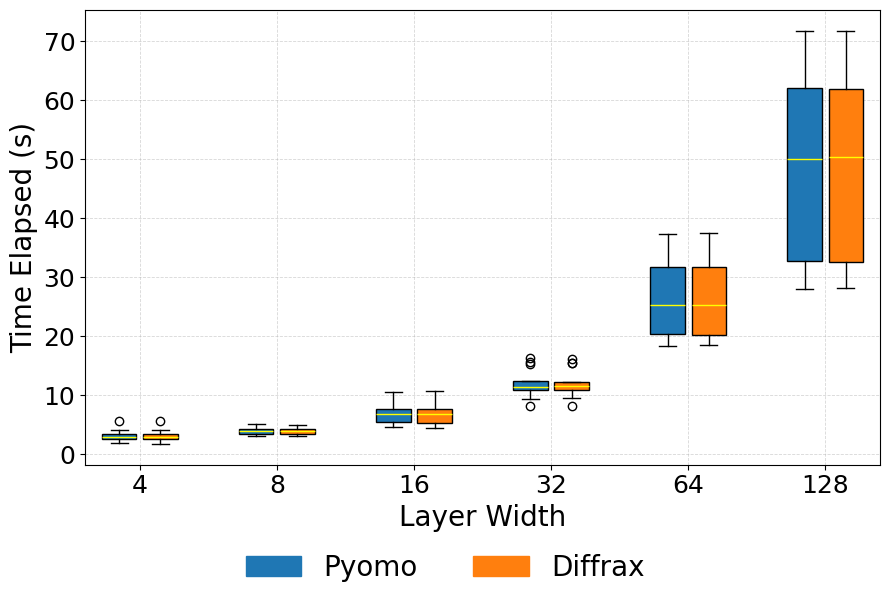

<Axes: xlabel='Layer Width', ylabel='Time Elapsed (s)'>

In [51]:
Graphs.plot_boxplots_custom(pyomo_times['times_elapsed'], jax_times['time'], pyomo_train.x_labels, 
            '',     
              'Time Elapsed (s)', color_labels=["Pyomo", "Diffrax"],
              x_label = "Layer Width",
              figsize=(9, 6),
              label_fontsize=20,
              tick_fontsize=18,
              legend_fontsize=20,
              title_fontsize=20,
              legend_bbox_y=-0.02,
              legend_ncol=2,
              y_log = False,
              line_colors="yellow"
              )

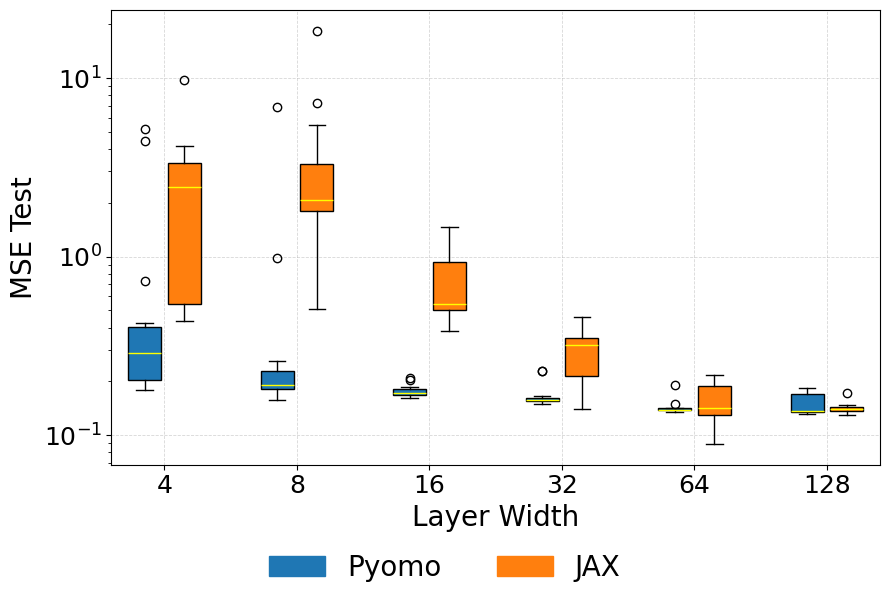

<Axes: xlabel='Layer Width', ylabel='MSE Test'>

In [52]:
Graphs.plot_boxplots_custom(pyomo_test['mse_coll_ode_test'], jax_test['mse_test_log'], pyomo_train.x_labels, 
            '',     
              'MSE Test', color_labels=["Pyomo", "JAX"],
              x_label = "Layer Width",
              figsize=(9, 6),
              label_fontsize=20,
              tick_fontsize=18,
              legend_fontsize=20,
              title_fontsize=20,
              legend_bbox_y=-0.02,
              legend_ncol=2,
              line_colors="yellow"
              )

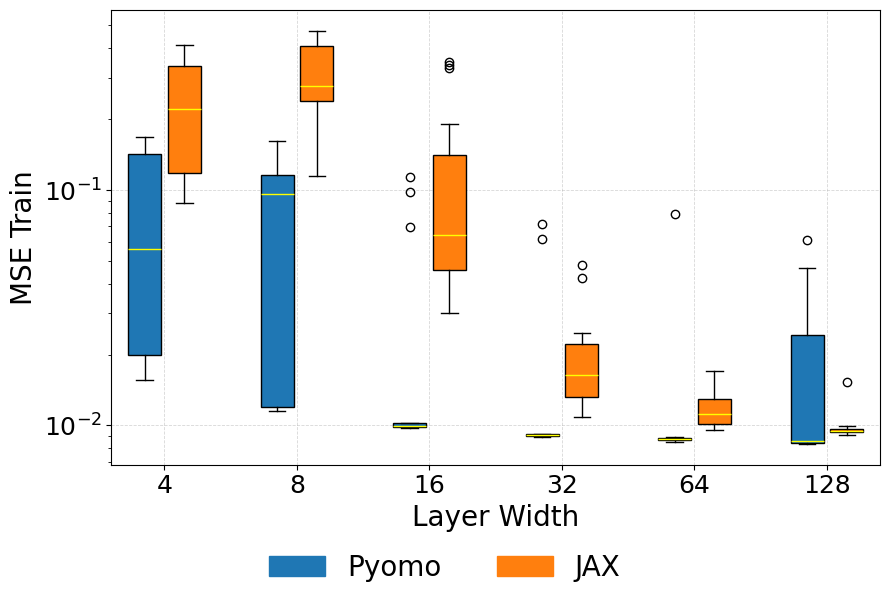

<Axes: xlabel='Layer Width', ylabel='MSE Train'>

In [53]:
Graphs.plot_boxplots_custom(pyomo_train['mse_coll_ode'], jax_train['mse_train_log'], pyomo_train.x_labels, 
            '',     
              'MSE Train', color_labels=["Pyomo", "JAX"],
              x_label = "Layer Width",
              figsize=(9, 6),
              label_fontsize=20,
              tick_fontsize=18,
              legend_fontsize=20,
              title_fontsize=20,
              legend_bbox_y=-0.02,
              legend_ncol=2,
              line_colors="yellow"
              )